# **Day 86: Remote Sensing Data for Machine Learning**
*Module 13 - Remote Sensing ML and Publication Projects*

Welcome to the final module. Everything from Days 1-85 now comes together on **Earth observation** data. Today we learn what satellite data are, how they are stored, and how to turn rasters and vectors into the `X` and `y` that ML models need. We also create the **study area** used by the projects in Days 88-91.

> Satellite images are stacks of measurements: optical bands record reflected sunlight, radar records backscattered microwaves and works through clouds, and terrain data describes elevation and slope. Before ML we must understand resolution, projections, clouds and how to sample training points.
>
> *Example:* Sentinel-2 sees crops in colour and near-infrared every 5 days, while Sentinel-1 radar still sees the fields under monsoon clouds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio, geopandas as gpd
from rasterio.windows import Window
from pathlib import Path
from shapely.geometry import Point, box
import rs_utils as ru                    # helper module in this folder (synthetic study area, I/O, sampling, accuracy, maps)
DATA = Path("data/study_area"); DATA.mkdir(parents=True, exist_ok=True)
print("rasterio", rasterio.__version__, "| geopandas", gpd.__version__)

rasterio 1.5.2 | geopandas 1.2.0


## **1. Physics in One Page**
A passive optical sensor measures sunlight reflected by the surface in several **bands**. After atmospheric correction we get **surface reflectance** (0-1). Different materials have different **spectral signatures**:
- **Vegetation**: absorbs red (chlorophyll), reflects strongly in near-infrared (leaf structure): the "red edge".
- **Water**: absorbs NIR and SWIR: very dark beyond the visible.
- **Soil / built-up**: brighter in SWIR; built-up relatively flat.

SAR (Sentinel-1) is **active**: it sends microwaves and measures backscatter (dB). It sees through clouds, day and night, and responds to **structure and moisture** (smooth water is dark; buildings are bright through double bounce).

| Resolution | Meaning | Sentinel-2 | Landsat 8/9 | Sentinel-1 |
|---|---|---|---|---|
| Spatial | pixel size | 10 / 20 / 60 m | 30 m (15 m pan) | ~10 m (GRD) |
| Spectral | number/width of bands | 13 bands (VNIR, red edge, SWIR) | 11 bands incl. thermal | C-band, VV + VH |
| Temporal | revisit | 5 days (2 satellites) | 8 days (2 satellites) | 6-12 days |
| Radiometric | bit depth | 12 bit | 14 bit (L9) | - |

## **2. Create the Study Area Used in This Module**
Real projects start from downloaded imagery (Day 87). To keep every notebook runnable offline, `rs_utils` simulates a **realistic** 10 x 10 km landscape at 20 m resolution: a meandering river, a town with roads, coal-mining pits, deciduous forest on uplands, monsoon (kharif) rice and winter (rabi) crops in the valley, with six Sentinel-2-like dates (one monsoon date mostly cloudy), Sentinel-1 VV/VH with speckle, and a DEM. It is loosely modelled on the Damodar valley near Dhanbad (Jharkhand). **None of it is real data.**

In [2]:
area = ru.make_study_area(n=500, pixel=20.0, seed=0)
T = area["transform"]; H, W = area["lc"].shape
print("CRS:", area["crs"], "| pixel:", area["pixel"], "m | size:", H, "x", W, "| affine transform:\n", T)
print("Sentinel-2 stack (dates, bands, rows, cols):", area["s2"].shape, "| dates:", [d.strftime("%b") for d in area["dates"]])

CRS: EPSG:32645 | pixel: 20.0 m | size: 500 x 500 | affine transform:
 | 20.00, 0.00, 430000.00|
| 0.00,-20.00, 2640000.00|
| 0.00, 0.00, 1.00|
Sentinel-2 stack (dates, bands, rows, cols): (6, 10, 500, 500) | dates: ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov']


### Save as GeoTIFFs (how we will receive real data)
Reflectance is stored as **uint16 scaled by 10,000** (the Sentinel-2 convention), which halves the file size compared with float32.

In [3]:
s2_flat = (area["s2"].reshape(-1, H, W) * 10000).round().astype(np.uint16)
band_names = [f"{d.strftime('%Y%m%d')}_{b}" for d in area["dates"] for b in ru.S2_BANDS]
ru.write_geotiff(DATA / "s2_2024_stack.tif", s2_flat, T, nodata=0, band_names=band_names)
ru.write_geotiff(DATA / "s2_2024_cloudmask.tif", area["clouds"].astype(np.uint8), T, band_names=[d.strftime("%Y%m%d") for d in area["dates"]])
ru.write_geotiff(DATA / "s1_2024_vv_vh_db.tif", area["s1"].reshape(-1, H, W), T, band_names=[f"{d.strftime('%Y%m%d')}_{p}" for d in area["dates"] for p in ("VV", "VH")])
ru.write_geotiff(DATA / "terrain.tif", np.stack([area["dem"], area["slope"], area["aspect"], area["dist_river_m"], area["dist_road_m"]]), T,
                 band_names=["elevation_m", "slope_deg", "aspect_deg", "dist_river_m", "dist_road_m"])
ru.write_geotiff(DATA / "_truth_landcover_SIMULATION_ONLY.tif", area["lc"].astype(np.uint8), T, nodata=255, band_names=["landcover"])
for f in sorted(DATA.glob("*.tif")): print(f"{f.name:<40} {f.stat().st_size / 1e6:6.1f} MB")

_truth_landcover_SIMULATION_ONLY.tif        0.0 MB
s1_2024_vv_vh_db.tif                       10.5 MB
s2_2024_cloudmask.tif                       0.0 MB
s2_2024_stack.tif                          25.2 MB
terrain.tif                                 4.2 MB


The `_truth` raster exists only because the data are simulated: it lets us generate field samples and check maps. **In a real study we never have it**; we have field points and an independent validation sample (Day 88).

## **3. Reading Rasters With rasterio**

In [4]:
with rasterio.open(DATA / "s2_2024_stack.tif") as src:
    print("bands:", src.count, "| dtype:", src.dtypes[0], "| CRS:", src.crs, "| bounds:", src.bounds)
    print("first band names:", src.descriptions[:3])
    sep = {b: src.read(band_names.index(f"20240915_{b}") + 1).astype(np.float32) / 10000 for b in ru.S2_BANDS}   # read one date
    win = src.read(window=Window(col_off=200, row_off=100, width=64, height=64))       # read only a window: memory-safe
    print("window shape:", win.shape, "| its transform:", src.window_transform(Window(200, 100, 64, 64)))
    row, col = src.index(436000, 2635000)                                             # map coordinates -> pixel
    print("pixel containing (436000 E, 2635000 N):", (row, col), "-> its centre in map coords:", tuple(float(v) for v in src.xy(row, col)))

bands: 60 | dtype: uint16 | CRS: EPSG:32645 | bounds: BoundingBox(left=430000.0, bottom=2630000.0, right=440000.0, top=2640000.0)
first band names: ('20240115_B2', '20240115_B3', '20240115_B4')


window shape: (60, 64, 64) | its transform: | 20.00, 0.00, 434000.00|
| 0.00,-20.00, 2638000.00|
| 0.00, 0.00, 1.00|
pixel containing (436000 E, 2635000 N): (250, 300) -> its centre in map coords: (436010.0, 2634990.0)


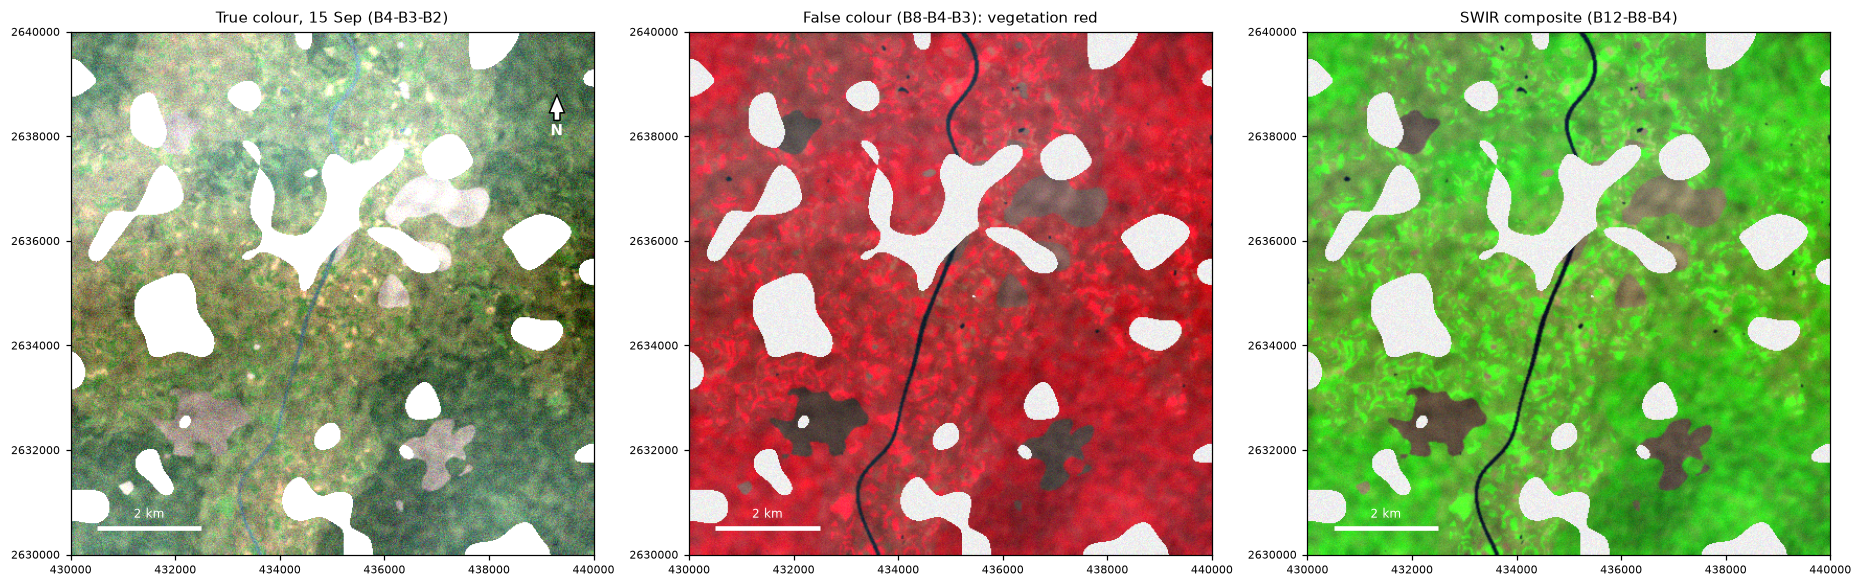

In [5]:
ext = ru.map_extent(T, (H, W))
ru.pub_style()
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
axes[0].imshow(np.clip(np.dstack([sep["B4"], sep["B3"], sep["B2"]]) / 0.15, 0, 1), extent=ext); axes[0].set_title("True colour, 15 Sep (B4-B3-B2)")
axes[1].imshow(np.clip(np.dstack([sep["B8"], sep["B4"], sep["B3"]]) / 0.4, 0, 1), extent=ext); axes[1].set_title("False colour (B8-B4-B3): vegetation red")
axes[2].imshow(np.clip(np.dstack([sep["B12"], sep["B8"], sep["B4"]]) / 0.4, 0, 1), extent=ext); axes[2].set_title("SWIR composite (B12-B8-B4)")
for ax in axes:
    ru.add_scalebar(ax, 2000, ext, color="w"); ax.ticklabel_format(style="plain"); ax.tick_params(labelsize=7)
ru.add_north_arrow(axes[0], color="w"); plt.tight_layout(); plt.show()

### Spectral signatures of the land-cover classes

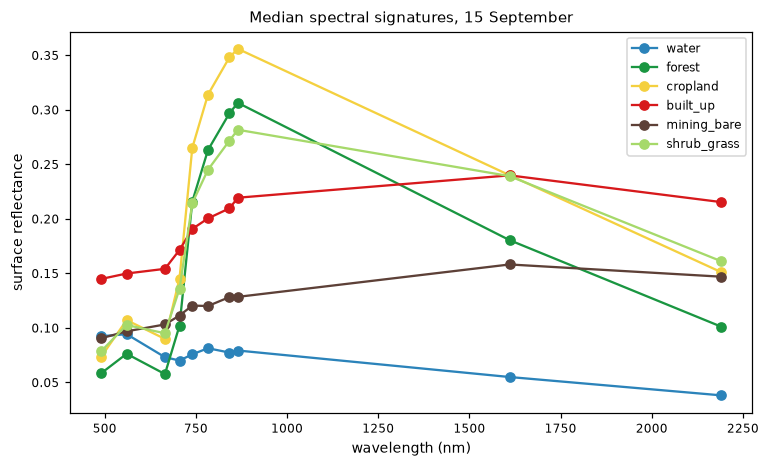

In [6]:
lc = area["lc"]; wl = [490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190]
plt.figure(figsize=(8, 4.5))
for k, name in enumerate(ru.LC_CLASSES):
    spec = np.array([np.median(sep[b][lc == k]) for b in ru.S2_BANDS])
    plt.plot(wl, spec, "o-", color=ru.LC_COLORS[k], label=name)
plt.xlabel("wavelength (nm)"); plt.ylabel("surface reflectance"); plt.legend(); plt.title("Median spectral signatures, 15 September"); plt.show()

## **4. Spectral Indices and Cloud Masking**
Indices compress physics into one number and are robust to illumination (Day 19). Cloudy pixels must be **masked** (Sentinel-2's Scene Classification Layer or s2cloudless; here the simulated mask) before compositing or feature extraction.

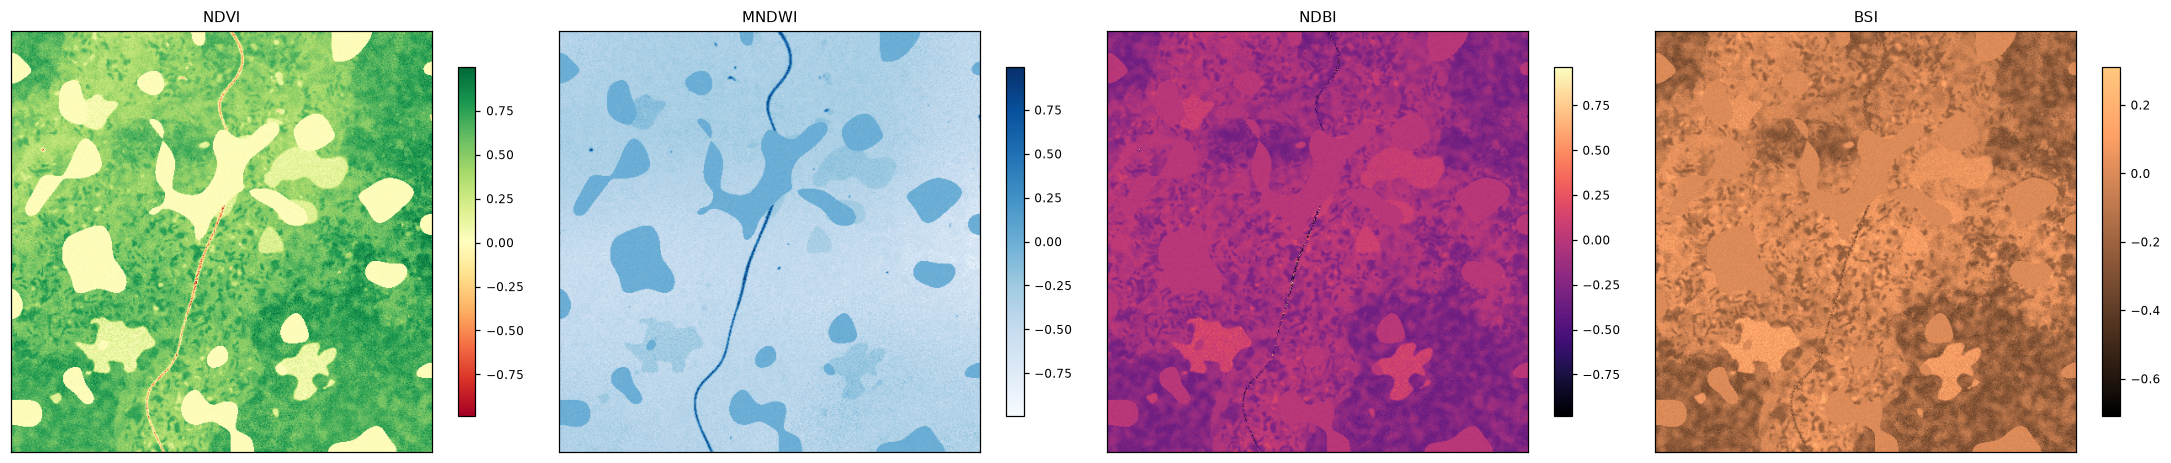

cloud fraction per date: {'Jan': 0.0, 'Mar': 0.0, 'May': 0.0, 'Jul': 0.4, 'Sep': 0.14, 'Nov': 0.0}


In [7]:
idx = ru.indices(sep)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, cmap) in zip(axes, [("NDVI", "RdYlGn"), ("MNDWI", "Blues"), ("NDBI", "magma"), ("BSI", "copper")]):
    im = ax.imshow(idx[name], cmap=cmap, extent=ext); ax.set_title(name); fig.colorbar(im, ax=ax, shrink=0.75); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

with rasterio.open(DATA / "s2_2024_cloudmask.tif") as src: clouds = src.read().astype(bool)
print("cloud fraction per date:", dict(zip([d.strftime("%b") for d in area["dates"]], clouds.mean((1, 2)).round(2).tolist())))

## **5. Vectors With geopandas: Field Points**
Ground truth arrives as GPS points or polygons (field survey, photo-interpretation). Here we simulate 600 field points: GPS positions with ~8 m error and 3% labelling mistakes.

In [8]:
rng = np.random.default_rng(86)
r_, c_, lab = ru.stratified_random_sample(lc, 100, seed=1)
x, y = ru.pixel_centres(T, r_, c_)
x, y = x + rng.normal(0, 8, len(x)), y + rng.normal(0, 8, len(y))                      # GPS error
lab_obs = np.where(rng.random(len(lab)) < 0.03, rng.integers(0, 6, len(lab)), lab)       # occasional labelling mistakes
field = gpd.GeoDataFrame({"point_id": np.arange(len(lab)), "class_id": lab_obs, "class": np.array(ru.LC_CLASSES)[lab_obs]},
                         geometry=[Point(xx, yy) for xx, yy in zip(x, y)], crs=ru.CRS)
field.to_file(DATA / "field_points.gpkg", driver="GPKG")
print(field.head()); print("\nCRS:", field.crs, "| in lat/lon:", field.to_crs("EPSG:4326").geometry.iloc[0])

   point_id  class_id  class                        geometry
0         0         0  water  POINT (434276.817 2633526.825)
1         1         0  water  POINT (434507.963 2634398.153)
2         2         0  water  POINT (436295.366 2638924.625)
3         3         0  water  POINT (435315.783 2638899.591)
4         4         0  water    POINT (435223.53 2636473.97)

CRS: EPSG:32645 | in lat/lon: POINT (86.35476942145294 23.81168238199503)


## **6. From Images + Points to a Training Table**
The central RS-ML operation: **sample the raster values at each point** and build a table with one row per point and one column per feature (bands x dates + indices + terrain). Then any model from Days 22-85 can be trained.

In [9]:
def extract_at_points(raster_path, gdf, scale=1.0):
    with rasterio.open(raster_path) as src:
        coords = [(p.x, p.y) for p in gdf.geometry]
        vals = np.array(list(src.sample(coords)), dtype=np.float32) * scale
        names = [d or f"b{i + 1}" for i, d in enumerate(src.descriptions)]
    return pd.DataFrame(vals, columns=names, index=gdf.index)

tab = pd.concat([field[["point_id", "class_id", "class"]],
                 extract_at_points(DATA / "s2_2024_stack.tif", field, 1 / 10000),
                 extract_at_points(DATA / "s1_2024_vv_vh_db.tif", field),
                 extract_at_points(DATA / "terrain.tif", field)], axis=1)
tab["x"], tab["y"] = field.geometry.x, field.geometry.y
for d in area["dates"]:
    p = d.strftime("%Y%m%d"); b = {k: tab[f"{p}_{k}"] for k in ru.S2_BANDS}
    for name, v in ru.indices(b).items(): tab[f"{p}_{name}"] = v
tab.to_csv(DATA / "training_table.csv", index=False)
print("training table:", tab.shape); tab.iloc[:3, :8]

training table: (600, 124)


,point_id,class_id,class,20240115_B2,20240115_B3,20240115_B4,20240115_B5,20240115_B6
0,0,0,water,0.0987,0.0938,0.0659,0.0771,0.0744
1,1,0,water,0.0854,0.0718,0.0944,0.0731,0.0521
2,2,0,water,0.0902,0.0799,0.0689,0.0723,0.0930


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
feat_cols = [c for c in tab.columns if c not in ("point_id", "class_id", "class", "x", "y")]
print(f"{len(feat_cols)} features | random-forest 5-fold CV accuracy (random split, optimistic, see Day 88): "
      f"{cross_val_score(RandomForestClassifier(300, random_state=0, n_jobs=-1), tab[feat_cols], tab.class_id, cv=5).mean():.3f}")

119 features | random-forest 5-fold CV accuracy (random split, optimistic, see Day 88): 0.913


## **7. Temporal Compositing and Time-Series Features**
A **median composite** over a season removes clouds and noise; per-pixel time-series features (max NDVI, amplitude, date of peak) capture phenology (Day 51 of the classic course, Day 92 here).

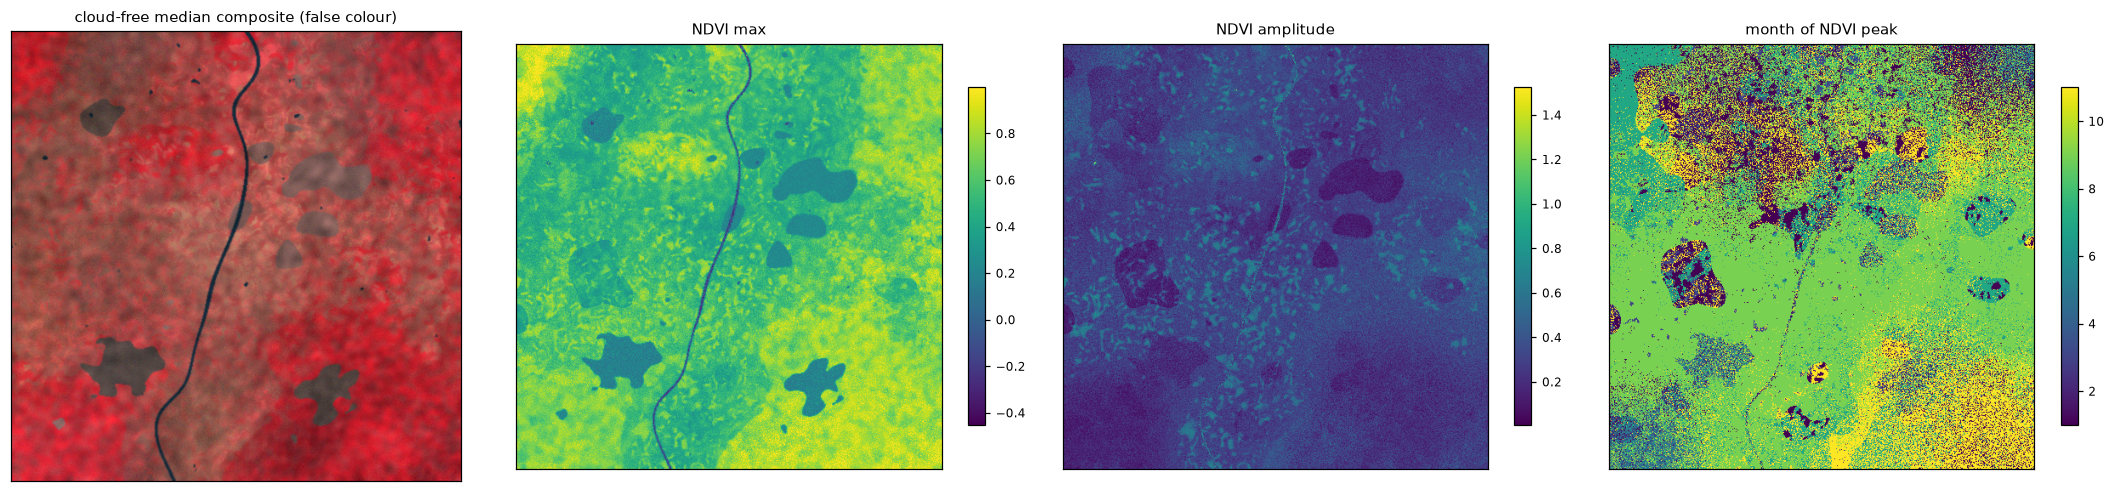

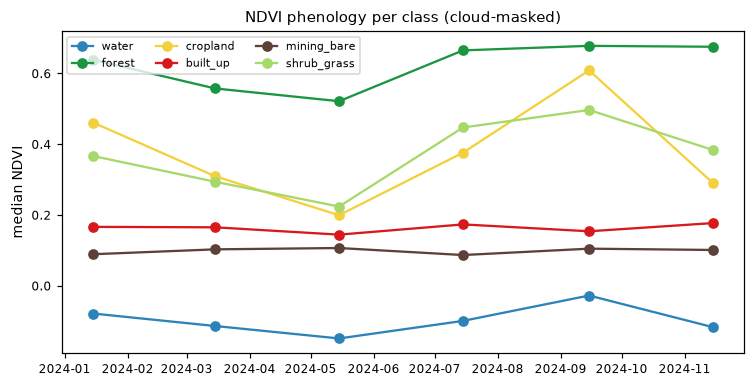

In [11]:
s2 = area["s2"].astype(np.float32); s2m = np.where(area["clouds"][:, None], np.nan, s2)
median = np.nanmedian(s2m, axis=0)
ndvi_ts = (s2m[:, 6] - s2m[:, 2]) / (s2m[:, 6] + s2m[:, 2])
feats_ts = {"NDVI max": np.nanmax(ndvi_ts, 0), "NDVI amplitude": np.nanmax(ndvi_ts, 0) - np.nanmin(ndvi_ts, 0), "month of NDVI peak": np.nanargmax(np.nan_to_num(ndvi_ts, nan=-1), 0) * 2 + 1}
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
axes[0].imshow(np.clip(median[[6, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)); axes[0].set_title("cloud-free median composite (false colour)")
for ax, (k, v) in zip(axes[1:], feats_ts.items()):
    im = ax.imshow(v, cmap="viridis"); ax.set_title(k); fig.colorbar(im, ax=ax, shrink=0.75)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
plt.figure(figsize=(8, 3.8))
for k, name in enumerate(ru.LC_CLASSES):
    plt.plot(area["dates"], np.nanmedian(ndvi_ts[:, lc == k], axis=1), "o-", color=ru.LC_COLORS[k], label=name)
plt.ylabel("median NDVI"); plt.legend(fontsize=7, ncol=3); plt.title("NDVI phenology per class (cloud-masked)"); plt.show()

# **Part 2: Going Deeper - Reprojection, Resampling and Alignment**

Combining sources (Sentinel-2 at 10/20 m, Landsat at 30 m, a DEM in geographic coordinates, a soil map) requires a **common grid**: same CRS, pixel size and alignment. Otherwise "the same pixel" in two layers is a different place, adding noise and leakage. Rules: **nearest neighbour** for categorical rasters (never average class codes), **bilinear/cubic** or **average** for continuous data; resample to the **coarsest** meaningful resolution for modelling, or aggregate fine data with `average`.

In [12]:
from rasterio.warp import reproject, Resampling, calculate_default_transform
src_crs, dst_crs = ru.CRS, "EPSG:4326"
dst_T, dw, dh = calculate_default_transform(src_crs, dst_crs, W, H, *rasterio.transform.array_bounds(H, W, T))
dem_ll = np.empty((dh, dw), np.float32)
reproject(area["dem"], dem_ll, src_transform=T, src_crs=src_crs, dst_transform=dst_T, dst_crs=dst_crs, resampling=Resampling.bilinear)
print(f"DEM reprojected to WGS84: {dem_ll.shape}, pixel size {dst_T.a:.6f} degrees")
from rasterio.transform import from_origin
T60 = from_origin(T.c, T.f, 60, 60); lc60_nn = np.empty((H // 3, W // 3), np.uint8); lc60_mode = np.empty_like(lc60_nn)
reproject(lc.astype(np.uint8), lc60_nn, src_transform=T, src_crs=src_crs, dst_transform=T60, dst_crs=src_crs, resampling=Resampling.nearest)
reproject(lc.astype(np.uint8), lc60_mode, src_transform=T, src_crs=src_crs, dst_transform=T60, dst_crs=src_crs, resampling=Resampling.mode)
dem60 = np.empty((H // 3, W // 3), np.float32)
reproject(area["dem"], dem60, src_transform=T, src_crs=src_crs, dst_transform=T60, dst_crs=src_crs, resampling=Resampling.average)
print("class shares at 20 m:", np.round(np.bincount(lc.ravel(), minlength=6) / lc.size, 3))
print("at 60 m, nearest    :", np.round(np.bincount(lc60_nn.ravel(), minlength=6) / lc60_nn.size, 3))
print("at 60 m, mode       :", np.round(np.bincount(lc60_mode.ravel(), minlength=6) / lc60_mode.size, 3), " <- small/thin classes shrink when aggregating")

DEM reprojected to WGS84: (481, 523), pixel size 0.000189 degrees
class shares at 20 m: [0.009 0.343 0.153 0.027 0.03  0.438]
at 60 m, nearest    : [0.009 0.339 0.154 0.027 0.03  0.441]
at 60 m, mode       : [0.009 0.34  0.145 0.027 0.03  0.449]  <- small/thin classes shrink when aggregating


## **Practice Problems**
1. Read only the NIR band (B8) of 15 January for a 100 x 100 window around the town and compute its mean.
2. Buffer each field point by 30 m (geopandas), and extract the **mean** NDVI within each buffer instead of the single pixel value. When is this better?
3. Compute the median NDVI per land-cover class for each date from the training table (not from the truth raster).
4. *(Advanced)* Write a 10 m version of the NDVI by bilinear resampling and explain why this does **not** create new information.

In [13]:
# Solution 1
with rasterio.open(DATA / "s2_2024_stack.tif") as src:
    b8_jan = src.read(band_names.index("20240115_B8") + 1, window=Window(260, 125, 100, 100)) / 10000
print("mean B8 near the town (Jan):", round(float(b8_jan.mean()), 4))
# Solution 2
buf = field.copy(); buf["geometry"] = field.buffer(30)
ndvi_sep = idx["NDVI"]
def zonal_mean(geom):
    minx, miny, maxx, maxy = geom.bounds; r0, c0 = ru.points_to_rowcol(T, [minx], [maxy]); r1, c1 = ru.points_to_rowcol(T, [maxx], [miny])
    return float(ndvi_sep[max(r0[0], 0):r1[0] + 1, max(c0[0], 0):c1[0] + 1].mean())
buf["ndvi_mean_30m"] = buf.geometry.apply(zonal_mean)
print(buf[["class", "ndvi_mean_30m"]].head(), "\n-> buffers average out GPS error and mixed pixels for homogeneous fields; bad for small objects")
# Solution 3
print(tab.groupby("class")[[f"{d.strftime('%Y%m%d')}_NDVI" for d in area["dates"]]].median().round(2))

mean B8 near the town (Jan): 0.2454
   class  ndvi_mean_30m
0  water       0.049859
1  water      -0.298906
2  water       0.220338
3  water       0.133842
4  water      -0.003689 
-> buffers average out GPS error and mixed pixels for homogeneous fields; bad for small objects
             20240115_NDVI  20240315_NDVI  20240515_NDVI  20240715_NDVI  \
class                                                                     
built_up              0.18           0.17           0.15           0.17   
cropland              0.47           0.30           0.20           0.22   
forest                0.64           0.56           0.51           0.55   
mining_bare           0.09           0.10           0.11           0.03   
shrub_grass           0.37           0.29           0.22           0.06   
water                -0.04          -0.14          -0.11          -0.03   

             20240915_NDVI  20241115_NDVI  
class                                      
built_up              0.12        

## **Key References**
- Drusch, M. et al. (2012). Sentinel-2: ESA's optical high-resolution mission for GMES operational services. *Remote Sensing of Environment*, 120, 25-36.
- Torres, R. et al. (2012). GMES Sentinel-1 mission. *Remote Sensing of Environment*, 120, 9-24.
- Wulder, M. A. et al. (2019). Current status of Landsat program, science, and applications. *Remote Sensing of Environment*, 225, 127-147.
- Main-Knorn, M. et al. (2017). Sen2Cor for Sentinel-2. *Proc. SPIE 10427, Image and Signal Processing for Remote Sensing XXIII*.
- Jensen, J. R. (2015). *Introductory Digital Image Processing: A Remote Sensing Perspective* (4th ed.). Pearson.
- Gillies, S. et al. (2013-). Rasterio: geospatial raster I/O for Python programmers. github.com/rasterio/rasterio.